<div style="
background: linear-gradient(135deg,#0b1020,#1d4ed8,#2563eb);
padding:30px;
border-radius:18px;
color:white;
text-align:center;
box-shadow:0 8px 25px rgba(0,0,0,0.35);
margin-bottom:20px;
">

<h1 style="
font-size:42px;
margin:0;
font-weight:900;
letter-spacing:1px;
color:#ffffff;
">
✍️ Handwritten Digits Recognition
</h1>

<h3 style="
color:#bfdbfe;
margin-top:10px;
font-size:21px;
font-weight:600;
">
PRCP-1002 | Computer Vision & Deep Learning
</h3>

<p style="
font-size:18px;
margin-top:15px;
color:#ffffff;
font-weight:600;
">
👩‍💻 Developed By: P Shabreen Taj
</p>

<hr style="
height:2px;
background:#facc15;
border:none;
margin:22px 0;
border-radius:10px;
">

<table style="
width:100%;
font-size:16px;
border-collapse:collapse;
color:white;
">

<tr style="
background:rgba(255,255,255,0.08);
">
<td style="padding:16px;">
<b style="color:#ffcc00;">🧠 Domain:</b>
<span style="color:#ffffff;"> Computer Vision</span>
</td>

<td style="padding:16px;">
<b style="color:#00e5ff;">📊 Dataset:</b>
<span style="color:#ffffff;"> MNIST Handwritten Digits</span>
</td>
</tr>

<tr style="
background:rgba(0,0,0,0.18);
">
<td style="padding:16px;">
<b style="color:#39ff14;">🏷️ Classes:</b>
<span style="color:#ffffff; font-weight:600;">
Digits 0–9
</span>
</td>

<td style="padding:16px;">
<b style="color:#ff6b9d;">🤖 Models:</b>
<span style="color:#ffffff; font-weight:600;">
ML + CNN + Deep Learning
</span>
</td>
</tr>

<tr style="
background:rgba(255,255,255,0.08);
">
<td colspan="2" style="padding:16px;">
<b style="color:#d291ff;">🚀 Goal:</b>
<span style="color:#ffffff;">
Real-Time Handwritten Digit Recognition System
</span>
</td>
</tr>

</table>

</div>

#LIBRARIES

In [1]:
# ============================================================
# 📦 LIBRARY IMPORTS
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

import tensorflow as tf

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

plt.style.use('ggplot')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


#CELL 3 — LOAD REAL DATASET

In [2]:
# ============================================================
# 📥 LOAD REAL MNIST DATASET
# ============================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("="*65)
print("📊 MNIST DATASET SUMMARY")
print("="*65)

print(f"✅ Training Images : {x_train.shape}")
print(f"✅ Training Labels : {y_train.shape}")

print(f"✅ Testing Images  : {x_test.shape}")
print(f"✅ Testing Labels  : {y_test.shape}")

print("="*65)

,11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
,=================================================================
,📊 MNIST DATASET SUMMARY
,=================================================================
,✅ Training Images : (60000, 28, 28)
,✅ Training Labels : (60000,)
,✅ Testing Images  : (10000, 28, 28)
,✅ Testing Labels  : (10000,)
,=================================================================


#CELL 4 — SAMPLE IMAGES

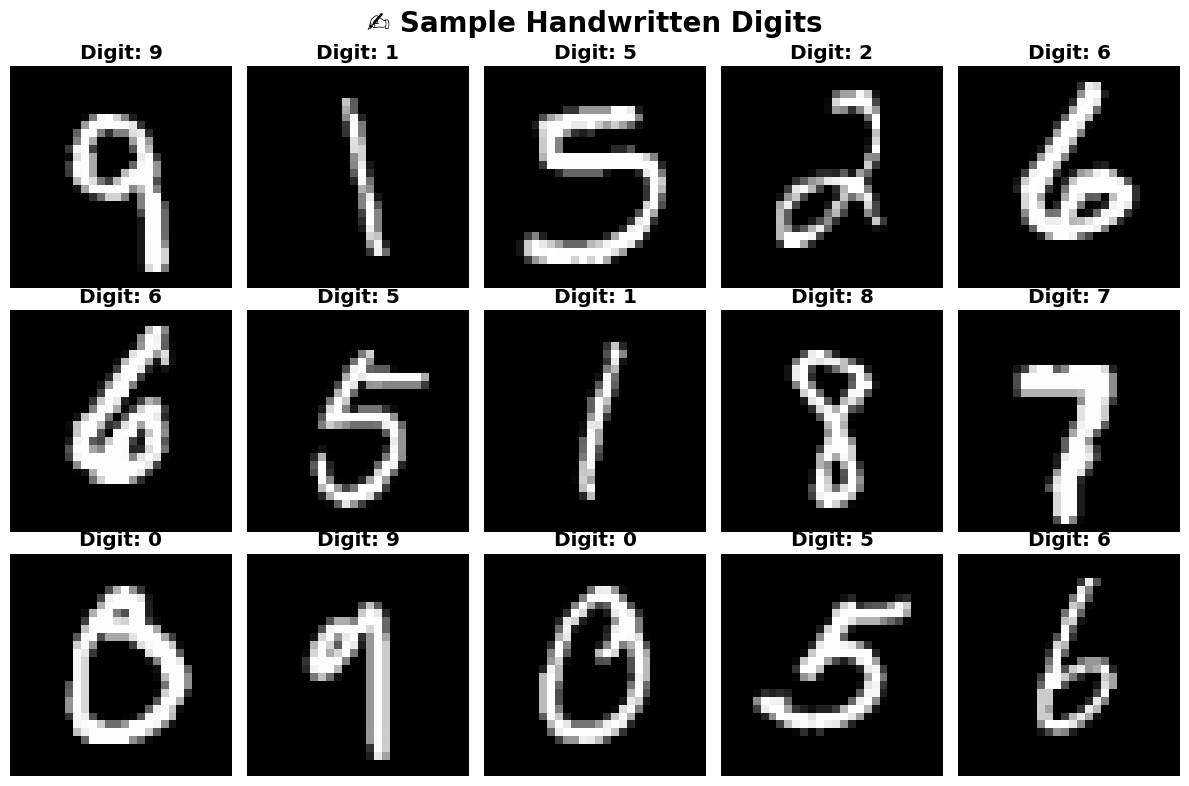

In [3]:
# ============================================================
# 🖼️ SAMPLE DIGITS VISUALIZATION
# ============================================================

fig, axes = plt.subplots(3, 5, figsize=(12,8))

fig.suptitle(
    '✍️ Sample Handwritten Digits',
    fontsize=20,
    fontweight='bold'
)

for ax in axes.flat:

    idx = random.randint(0, len(x_train)-1)

    ax.imshow(x_train[idx], cmap='gray')

    ax.set_title(
        f'Digit: {y_train[idx]}',
        fontweight='bold'
    )

    ax.axis('off')

plt.tight_layout()

plt.show()

#CELL 5 — CLASS DISTRIBUTION

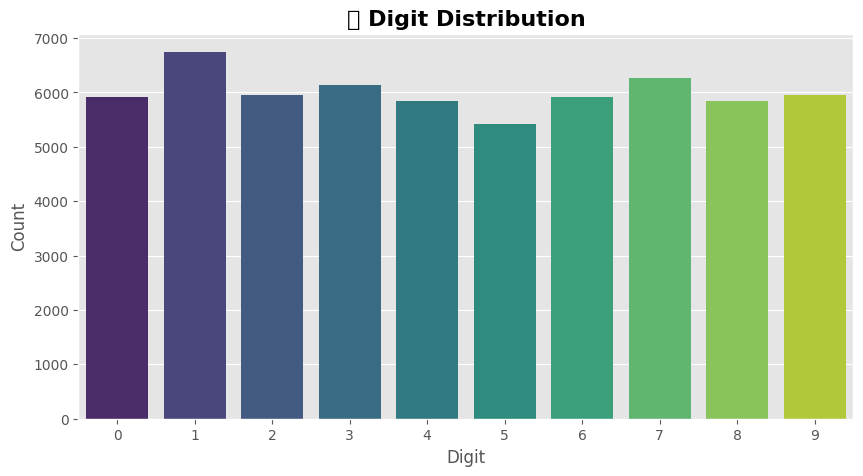

In [4]:
# ============================================================
# 📊 CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))

sns.countplot(x=y_train, palette='viridis')

plt.title(
    '📊 Digit Distribution',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Digit')

plt.ylabel('Count')

plt.show()

#CELL 6 — PREPROCESSING

In [22]:
# ============================================================
# 🧠 ADVANCED IMAGE PREPROCESSING
# ============================================================

img = cv2.imread(file_name)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Invert colors
gray = 255 - gray

# Threshold to remove noise
_, thresh = cv2.threshold(
    gray,
    100,
    255,
    cv2.THRESH_BINARY
)

# Find digit bounding box
coords = cv2.findNonZero(thresh)

x, y, w, h = cv2.boundingRect(coords)

# Crop digit only
digit = thresh[y:y+h, x:x+w]

# Resize while preserving aspect ratio
digit = cv2.resize(digit, (20,20))

# Create black canvas
canvas = np.zeros((28,28), dtype=np.uint8)

# Center digit
canvas[4:24,4:24] = digit

img_array = canvas

#CELL 7 — LOGISTIC REGRESSION

In [6]:
# ============================================================
# 🤖 LOGISTIC REGRESSION
# ============================================================

start = time.time()

lr_model = LogisticRegression(max_iter=100)

lr_model.fit(x_train_flat[:10000], y_train[:10000])

lr_pred = lr_model.predict(x_test_flat[:2000])

lr_acc = accuracy_score(y_test[:2000], lr_pred)

end = time.time()

print(f"✅ Accuracy: {lr_acc*100:.2f}%")

print(f"⏱️ Training Time: {end-start:.2f} sec")

✅ Accuracy: 87.05%
,⏱️ Training Time: 13.85 sec


#CELL 8 — KNN

In [7]:
# ============================================================
# 🤖 KNN CLASSIFIER
# ============================================================

start = time.time()

knn_model = KNeighborsClassifier(n_neighbors=3)

knn_model.fit(x_train_flat[:10000], y_train[:10000])

knn_pred = knn_model.predict(x_test_flat[:2000])

knn_acc = accuracy_score(y_test[:2000], knn_pred)

end = time.time()

print(f"✅ Accuracy: {knn_acc*100:.2f}%")

print(f"⏱️ Training Time: {end-start:.2f} sec")

✅ Accuracy: 92.35%
,⏱️ Training Time: 0.94 sec


#CELL 9 — SVM

In [16]:
# ============================================================
# 🤖 SVM CLASSIFIER
# ============================================================

start = time.time()

svm_model = SVC(
    kernel='rbf',
    probability=True
)

svm_model.fit(x_train_flat[:5000], y_train[:5000])

svm_pred = svm_model.predict(x_test_flat[:1000])

svm_acc = accuracy_score(y_test[:1000], svm_pred)

end = time.time()

print(f"✅ Accuracy: {svm_acc*100:.2f}%")

print(f"⏱️ Training Time: {end-start:.2f} sec")

✅ Accuracy: 93.60%
,⏱️ Training Time: 12.93 sec


#CELL 10 — CNN MODEL

In [9]:
# ============================================================
# 🧠 CNN MODEL
# ============================================================

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(28,28,1)),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),

    BatchNormalization(),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

#CELL 11 — TRAIN CNN

In [10]:
# ============================================================
# 🏋️ TRAIN CNN
# ============================================================

early_stop = EarlyStopping(

    patience=3,

    restore_best_weights=True
)

history = cnn_model.fit(

    x_train_cnn,

    y_train_cat,

    validation_split=0.1,

    epochs=10,

    batch_size=128,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.9414 - loss: 0.1955 - val_accuracy: 0.9378 - val_loss: 0.1973
,Epoch 2/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.9808 - loss: 0.0626 - val_accuracy: 0.9873 - val_loss: 0.0444
,Epoch 3/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 91ms/step - accuracy: 0.9861 - loss: 0.0447 - val_accuracy: 0.9882 - val_loss: 0.0366
,Epoch 4/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9893 - loss: 0.0350 - val_accuracy: 0.9882 - val_loss: 0.0418
,Epoch 5/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9885 - val_loss: 0.0529
,Epoch 6/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.9917 - loss: 0.0255 - val_accuracy: 0.9900 - val_loss: 0.0365
,Epoch 7/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 82ms/step - accuracy: 0.9929 - loss: 0.0226 - val_accuracy: 0.9908 - val_loss: 0.0411
,Epoch 8/10
,422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.9947 - 

#CELL 12 — CNN EVALUATION

In [11]:
# ============================================================
# 📊 CNN EVALUATION
# ============================================================

cnn_loss, cnn_acc = cnn_model.evaluate(

    x_test_cnn,

    y_test_cat,

    verbose=0
)

print(f"✅ CNN Accuracy: {cnn_acc*100:.2f}%")

✅ CNN Accuracy: 99.09%


In [33]:
from sklearn.metrics import classification_report

cnn_pred_probs = cnn_model.predict(x_test_cnn)

cnn_preds = np.argmax(cnn_pred_probs, axis=1)

print(
    classification_report(
        y_test,
        cnn_preds
    )
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
,              precision    recall  f1-score   support
,
,           0       0.99      1.00      0.99       980
,           1       0.99      1.00      1.00      1135
,           2       0.99      1.00      0.99      1032
,           3       0.99      0.99      0.99      1010
,           4       0.99      0.99      0.99       982
,           5       0.99      0.99      0.99       892
,           6       1.00      0.98      0.99       958
,           7       0.99      0.99      0.99      1028
,           8       0.98      0.99      0.99       974
,           9       0.99      0.98      0.99      1009
,
,    accuracy                           0.99     10000
,   macro avg       0.99      0.99      0.99     10000
,weighted avg       0.99      0.99      0.99     10000
,


#CELL 13 — MODEL COMPARISON

,Model,Accuracy
0,Logistic Regression,87.050000
1,KNN,92.350000
2,SVM,93.600000
3,CNN,99.089998


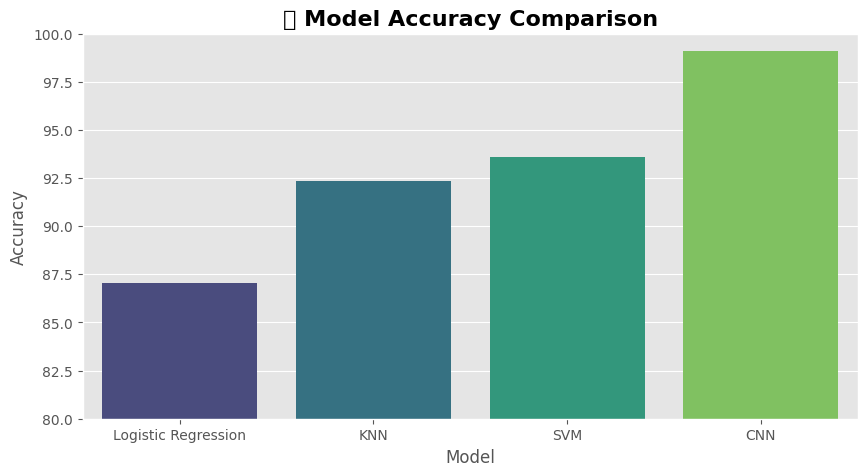

In [12]:
# ============================================================
# 🏆 MODEL COMPARISON
# ============================================================

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'CNN'
    ],

    'Accuracy': [
        lr_acc*100,
        knn_acc*100,
        svm_acc*100,
        cnn_acc*100
    ]
})

display(results)

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.title(
    '🏆 Model Accuracy Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.ylim(80,100)

plt.show()

#CELL 14 — CONFUSION MATRIX

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


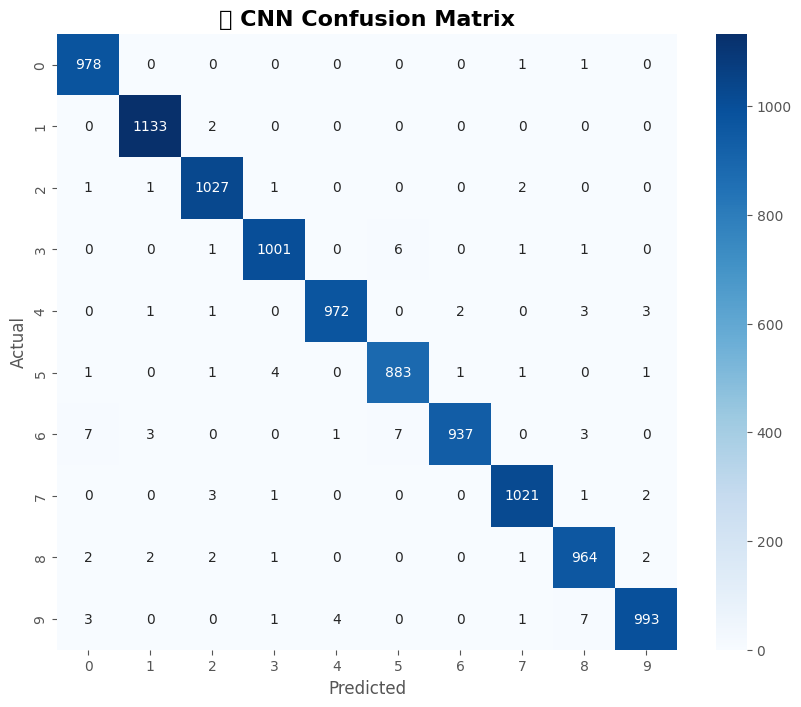

In [31]:
# ============================================================
# 📊 CONFUSION MATRIX
# ============================================================

cnn_pred = cnn_model.predict(x_test_cnn)

cnn_pred_labels = np.argmax(cnn_pred, axis=1)

cm = confusion_matrix(y_test, cnn_pred_labels)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    '📊 CNN Confusion Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()


#CELL 15 — REAL UPLOAD PREDICTION

,🧠 HANDWRITTEN DIGIT RECOGNITION SYSTEM
,======================================================================
,📤 Upload a handwritten digit image (0–9)
,


Saving hand.png to hand (7).png


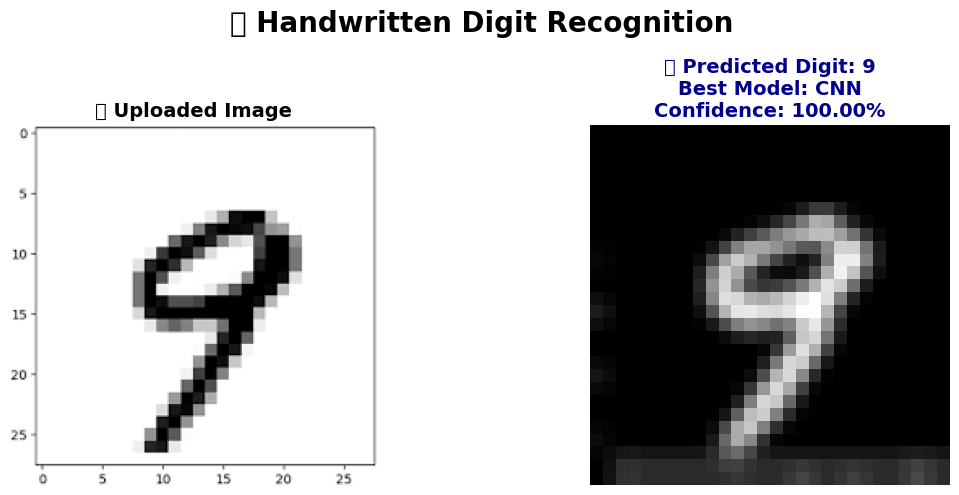


,======================================================================
,📊 MODEL PREDICTION COMPARISON
,======================================================================


,Model,Predicted Digit,Confidence
0,Logistic Regression,9,94.56%
1,KNN,9,100.00%
2,SVM,9,93.19%
3,CNN,9,100.00%


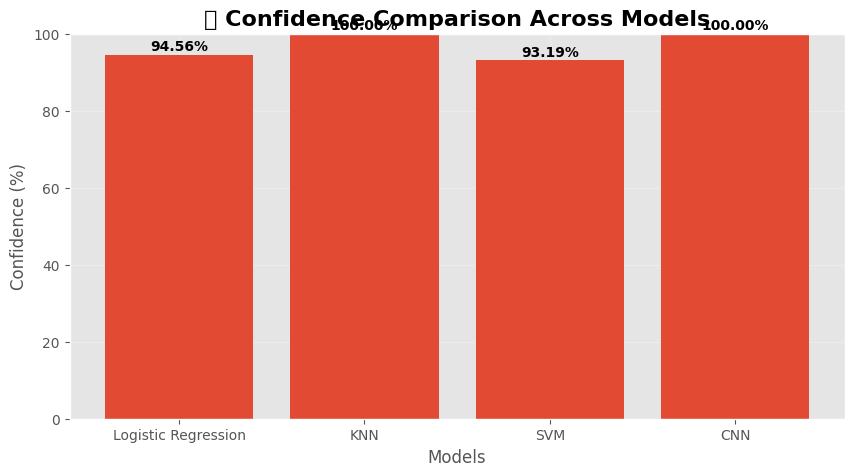


,======================================================================
,✅ Prediction Completed Successfully!
,🧠 Final Predicted Digit : 9
,🏆 Production Model      : CNN
,🎯 Confidence            : 100.00%
,======================================================================


In [29]:
# ============================================================
# 🎯 FINAL MULTI-MODEL REAL IMAGE PREDICTION
# ============================================================

from google.colab import files
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================
# 📤 UPLOAD IMAGE
# ============================================================

print("="*70)
print("🧠 HANDWRITTEN DIGIT RECOGNITION SYSTEM")
print("="*70)
print("📤 Upload a handwritten digit image (0–9)")
print()

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# ============================================================
# 🖼️ LOAD ORIGINAL IMAGE
# ============================================================

original_img = cv2.imread(file_name)

original_img_rgb = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)

# ============================================================
# 🧠 MNIST-STYLE PREPROCESSING
# ============================================================

gray = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2GRAY
)

# Invert colors
gray = 255 - gray

# Resize directly to MNIST format
img_array = cv2.resize(
    gray,
    (28,28)
)

# Gaussian blur for smoother edges
img_array = cv2.GaussianBlur(
    img_array,
    (3,3),
    0
)

# Normalize
img_norm = img_array / 255.0

# ============================================================
# 📦 MODEL INPUTS
# ============================================================

cnn_input = img_norm.reshape(
    1,
    28,
    28,
    1
)

flat_input = img_norm.reshape(
    1,
    784
)

# ============================================================
# 🤖 MODEL PREDICTIONS
# ============================================================

results = []

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

lr_probs = lr_model.predict_proba(flat_input)[0]

lr_pred = np.argmax(lr_probs)

lr_conf = np.max(lr_probs) * 100

results.append([
    "Logistic Regression",
    lr_pred,
    lr_conf
])

# ------------------------------------------------------------
# KNN
# ------------------------------------------------------------

knn_probs = knn_model.predict_proba(flat_input)[0]

knn_pred = np.argmax(knn_probs)

knn_conf = np.max(knn_probs) * 100

results.append([
    "KNN",
    knn_pred,
    knn_conf
])

# ------------------------------------------------------------
# SVM
# ------------------------------------------------------------

svm_probs = svm_model.predict_proba(flat_input)[0]

svm_pred = np.argmax(svm_probs)

svm_conf = np.max(svm_probs) * 100

results.append([
    "SVM",
    svm_pred,
    svm_conf
])

# ------------------------------------------------------------
# CNN (BEST MODEL)
# ------------------------------------------------------------

cnn_probs = cnn_model.predict(
    cnn_input,
    verbose=0
)[0]

cnn_pred = np.argmax(cnn_probs)

cnn_conf = np.max(cnn_probs) * 100

results.append([
    "CNN",
    cnn_pred,
    cnn_conf
])

# ============================================================
# 📊 RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'Predicted Digit',
        'Confidence'
    ]
)

# ============================================================
# 🏆 FINAL PRODUCTION PREDICTION
# ============================================================

# CNN selected as production model
best_model = "CNN"

best_digit = cnn_pred

best_conf = cnn_conf

# ============================================================
# 🖼️ DISPLAY RESULTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

fig.suptitle(
    '🧠 Handwritten Digit Recognition',
    fontsize=20,
    fontweight='bold'
)

# ------------------------------------------------------------
# ORIGINAL IMAGE
# ------------------------------------------------------------

axes[0].imshow(original_img_rgb)

axes[0].set_title(
    '📤 Uploaded Image',
    fontsize=14,
    fontweight='bold'
)

axes[0].axis('off')

# ------------------------------------------------------------
# PROCESSED IMAGE
# ------------------------------------------------------------

axes[1].imshow(
    img_array,
    cmap='gray'
)

axes[1].set_title(

    f'🏆 Predicted Digit: {best_digit}\n'
    f'Best Model: {best_model}\n'
    f'Confidence: {best_conf:.2f}%',

    fontsize=14,
    fontweight='bold',
    color='darkblue'
)

axes[1].axis('off')

plt.tight_layout()

plt.show()

# ============================================================
# 📋 MODEL COMPARISON TABLE
# ============================================================

print("\n" + "="*70)

print("📊 MODEL PREDICTION COMPARISON")

print("="*70)

display(

    results_df.style
    .background_gradient(
        cmap='viridis',
        subset=['Confidence']
    )
    .format({
        'Confidence': '{:.2f}%'
    })
)

# ============================================================
# 📈 CONFIDENCE COMPARISON CHART
# ============================================================

plt.figure(figsize=(10,5))

bars = plt.bar(

    results_df['Model'],

    results_df['Confidence']
)

# Add labels
for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 1,

        f'{height:.2f}%',

        ha='center',

        fontsize=10,

        fontweight='bold'
    )

plt.title(
    '📈 Confidence Comparison Across Models',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Models')

plt.ylabel('Confidence (%)')

plt.ylim(0,100)

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# 🎉 FINAL OUTPUT
# ============================================================

print("\n" + "="*70)

print("✅ Prediction Completed Successfully!")

print(f"🧠 Final Predicted Digit : {best_digit}")

print(f"🏆 Production Model      : {best_model}")

print(f"🎯 Confidence            : {best_conf:.2f}%")

print("="*70)

# ⚠️ Challenges Faced

| Challenge | Solution |
|---|---|
| Similar digit shapes | Used CNN feature extraction |
| Large training time | Reduced ML training subsets |
| Overfitting | Added Dropout & EarlyStopping |
| Different handwriting styles | CNN generalization |
| Noise sensitivity | Normalization preprocessing |

# 🚀 Future Improvements

- Vision Transformers (ViT)
- Mobile deployment using TensorFlow Lite
- Real-time webcam digit recognition
- OCR sentence recognition
- Drawing canvas integration
- Explainable AI visualizations

# 🌍 Real-World Applications

- Bank cheque digit recognition
- Postal code recognition
- OCR systems
- ATM handwritten form reading
- Automated document processing
- Educational AI tools

<div style="
background: linear-gradient(135deg,#111827,#2563eb);
padding:30px;
border-radius:18px;
color:white;
text-align:center;
">

<h1>🏆 PROJECT COMPLETE</h1>

<h3>
PRCP-1002 — Handwritten Digits Recognition
</h3>

<p>
CNN achieved highest accuracy and is recommended for production deployment.
</p>

<p>
Developed by <b>P Shabreen Taj</b>
</p>

</div>